In [1]:
import math
from functools import partial
from typing import Any, Callable, List, Optional, Sequence

import torch
from torch import nn, Tensor

from torchvision.models.mobilenetv3 import (
    MobileNetV3,
    InvertedResidualConfig,
    _mobilenet_v3_conf,
    _mobilenet_v3,
)

In [2]:
# ----------------------------
# 1. Define the CoordAtt Module
# ----------------------------
class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        """
        CoordAtt module that embeds positional information into channel attention.
        Here we assume inp==oup.
        """
        super().__init__()
        # Pool along each spatial dimension separately
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        # Use a simple intermediate channel reduction
        mip = max(8, inp // groups)

        # Shared 1x1 convolution to mix the two pooled features
        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        # Two separate convs to produce attention for height and width
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()

    def forward(self, x):
        identity = x
        n, c, h, w = x.size()
        # Pool along height and width
        x_h = self.pool_h(x)  # shape: (n, c, h, 1)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)  # shape: (n, c, w, 1)

        # Concatenate along the spatial dimension
        y = torch.cat([x_h, x_w], dim=2)  # shape: (n, c, h+w, 1)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y)
        # Split back to height and width attention maps
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        # Generate attention maps and apply sigmoid activation
        a_h = self.conv2(x_h).sigmoid()
        a_w = self.conv3(x_w).sigmoid()

        # Expand and multiply with the input feature
        a_h = a_h.expand(-1, -1, h, w)
        a_w = a_w.expand(-1, -1, h, w)
        out = identity * a_h * a_w
        return out

# ----------------------------
# 2. Create CA-enabled Inverted Residual Block for MobileNetV3
# ----------------------------
class InvertedResidualCA(nn.Module):
    """
    This is a variant of MobileNetV3's InvertedResidual block that uses
    the CoordAtt module instead of SqueezeExcitation when use_se is True.
    """
    def __init__(
        self,
        cnf: InvertedResidualConfig,
        norm_layer: Callable[..., nn.Module],
        attn_layer: Optional[Callable[..., nn.Module]] = None,
    ):
        super().__init__()
        if not (1 <= cnf.stride <= 2):
            raise ValueError("illegal stride value")
        self.use_res_connect = cnf.stride == 1 and cnf.input_channels == cnf.out_channels

        layers: List[nn.Module] = []
        activation_layer = nn.Hardswish if cnf.use_hs else nn.ReLU

        # Expand phase: 1x1 conv (if needed)
        if cnf.expanded_channels != cnf.input_channels:
            layers.append(
                nn.Sequential(
                    nn.Conv2d(cnf.input_channels, cnf.expanded_channels, kernel_size=1, bias=False),
                    norm_layer(cnf.expanded_channels),
                    activation_layer(inplace=True),
                )
            )

        # Depthwise convolution
        stride = 1 if cnf.dilation > 1 else cnf.stride
        layers.append(
            nn.Sequential(
                nn.Conv2d(
                    cnf.expanded_channels,
                    cnf.expanded_channels,
                    kernel_size=cnf.kernel,
                    stride=stride,
                    padding=cnf.kernel // 2,
                    dilation=cnf.dilation,
                    groups=cnf.expanded_channels,
                    bias=False,
                ),
                norm_layer(cnf.expanded_channels),
                activation_layer(inplace=True),
            )
        )

        # Attention module: if use_se is True, use CoordAtt if provided;
        # otherwise use the original SElayer.
        if cnf.use_se:
            if attn_layer is not None:
                layers.append(attn_layer(cnf.expanded_channels, cnf.expanded_channels))
            else:
                from torchvision.models.mobilenetv3 import SqueezeExcitation as SElayer
                squeeze_channels = (cnf.expanded_channels // 4)
                from torchvision.models.mobilenetv3 import _make_divisible
                squeeze_channels = _make_divisible(squeeze_channels, 8)
                layers.append(SElayer(cnf.expanded_channels, squeeze_channels))

        # Project phase: 1x1 conv (no activation)
        layers.append(
            nn.Sequential(
                nn.Conv2d(cnf.expanded_channels, cnf.out_channels, kernel_size=1, bias=False),
                norm_layer(cnf.out_channels),
            )
        )
        self.block = nn.Sequential(*layers)
        self.out_channels = cnf.out_channels
        self._is_cn = cnf.stride > 1

    def forward(self, input: Tensor) -> Tensor:
        result = self.block(input)
        if self.use_res_connect:
            result += input
        return result

# ----------------------------
# 3. Build MobileNetV3 Small with CA Module
# ----------------------------
def mobilenet_v3_ca_small(*, weights: Optional[Any] = None, progress: bool = True, **kwargs: Any) -> MobileNetV3:
    """
    Constructs a MobileNetV3 small network that integrates the CoordAtt module
    (CA) in place of the original squeeze-excitation blocks.

    Args:
        weights: Optional pretrained weights.
        progress: If True, display a progress bar.
        **kwargs: Additional arguments passed to the MobileNetV3 constructor.
    """
    # Get configuration for MobileNetV3 small.
    inverted_residual_setting, last_channel = _mobilenet_v3_conf("mobilenet_v3_small", **kwargs)

    # Use our CA-enabled block instead of the original InvertedResidual.
    block = lambda cnf, norm_layer: InvertedResidualCA(cnf, norm_layer, attn_layer=CoordAtt)

    # Build the model with the modified block.
    model = MobileNetV3(inverted_residual_setting, last_channel, block=block, **kwargs)

    if weights is not None:
        state_dict = weights.get_state_dict(progress=progress, check_hash=True)
        model.load_state_dict(state_dict)
    return model

In [3]:
import os
import zipfile
import time
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [4]:
!pip install grad-cam

In [5]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [6]:
# Alias our function for easier usage.
MobileNetV3SmallCA = mobilenet_v3_ca_small

In [7]:
class GradCAMWrapper:
    def __init__(self, model):
        self.model = model
        # Pointing to the last feature layer.
        self.target_layers = [self.model.features[-1]]
        self.cam = GradCAM(model=self.model,
                           target_layers=self.target_layers,
                           #use_cuda=torch.cuda.is_available()
                           )

    def visualize(self, input_tensor, rgb_img=None):
        grayscale_cam = self.cam(input_tensor=input_tensor)
        grayscale_cam = grayscale_cam[0, :]
        if rgb_img is None:
            rgb_img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
            rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        return visualization

def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    train_transforms = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    val_test_transforms = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), val_test_transforms)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, val_loader, test_loader

def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='o')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy', marker='o')
    plt.plot(val_accs, label='Val Accuracy', marker='o')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=16):
    model.load_state_dict(torch.load('best_model.pth'))
    model.to(device).eval()

    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    plt.figure(figsize=(12, 12))
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        plt.subplot(4, 4, idx + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_gradcam_examples(model, test_loader, device, class_names, num_examples=16):
    cam_wrapper = GradCAMWrapper(model)
    model.eval()

    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    plt.figure(figsize=(12, 12))
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        visualization = cam_wrapper.visualize(inputs[idx].unsqueeze(0), img)
        plt.subplot(4, 4, idx + 1)
        plt.imshow(visualization)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_loader, device, class_names):
    best_model_path = 'best_model.pth'
    model.load_state_dict(torch.load(best_model_path))
    model.to(device)
    model.eval()
    y_true, y_pred = [], []
    total, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [8]:
# ----------------------------
# Mount Google Drive and prepare dataset paths
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
num_epochs_initial = 15
learning_rate_initial = 3e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Extract dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
# 1. Load the pretrained MobileNetV3 small model and get its state dict.
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
pretrained_model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
pretrained_state_dict = pretrained_model.state_dict()

# 2. Instantiate your CA-enabled model for MobileNetV3 small.
model = MobileNetV3SmallCA(num_classes=num_classes)

# 3. Get the state dict of your CA-enabled model.
model_state_dict = model.state_dict()

# 4. Update matching layers from the pretrained state dict.
for name, param in pretrained_state_dict.items():
    if name in model_state_dict and model_state_dict[name].shape == param.shape:
        model_state_dict[name] = param

# 5. Load the updated state dict into your model.
model.load_state_dict(model_state_dict)
print("Loaded pretrained weights for matching layers.")

Loaded pretrained weights for matching layers.


In [11]:
!pip install torchinfo

In [12]:
from torchinfo import summary
print("\nDetailed Model Architecture (After modifying classifier):")
print(model)
print("\nUpdated Model Summary (After modifying classifier):")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Detailed Model Architecture (After modifying classifier):
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidualCA(
      (block): Sequential(
        (0): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): CoordAtt(
          (pool_h): AdaptiveAvgPool2d(output_size=(None, 1))
          (pool_w): AdaptiveAvgPool2d(output_size=(1, None))
          (conv1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(8,

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualCA: 2-2                     [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           904
│    └─InvertedResidualCA: 2-3                     [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           3,864
│    └─InvertedResidualCA: 2-4                     [1, 24, 32, 32]           --
│    │    └─Sequential: 3-6   

In [13]:
# ====== Helper Functions for Freezing / Unfreezing ======
def freeze_all_except_classifier_and_attention(model):
    """
    Freeze all parameters except those in the classifier and attention modules.
    """
    for param in model.parameters():
        param.requires_grad = False

    for name, param in model.named_parameters():
        if "classifier" in name:
            param.requires_grad = True

    def unfreeze_attention(module):
        for child in module.children():
            if isinstance(child, CoordAtt):
                for p in child.parameters():
                    p.requires_grad = True
            else:
                unfreeze_attention(child)
    unfreeze_attention(model)

def unfreeze_last_n_layers_and_attention(model, n):
    """
    Unfreeze the last 'n' parameters and keep attention modules trainable.
    """
    params = list(model.named_parameters())
    for name, param in params[-n:]:
        param.requires_grad = True

    def unfreeze_attention(module):
        for child in module.children():
            if isinstance(child, CoordAtt):
                for p in child.parameters():
                    p.requires_grad = True
            else:
                unfreeze_attention(child)
    unfreeze_attention(model)

def unfreeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = True

def print_model_summary(model, input_size=(1, 3, 256, 256)):
    print("\n==== Model Summary ====")
    print(summary(model, input_size=input_size))
    print("=======================\n")

def show_visualizations(model, test_loader, device, class_names):
    print("\nTrue vs Predicted Images:")
    plot_true_vs_predicted(model, test_loader, device, class_names)
    print("\nGrad-CAM Visualizations:")
    show_gradcam_examples(model, test_loader, device, class_names)

In [14]:
# ====== Stage 1: Train Only the Classifier ======
print("Stage 1: Training only the classifier layer.")
freeze_all_except_classifier_and_attention(model)
print_model_summary(model)

Stage 1: Training only the classifier layer.

==== Model Summary ====
Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualCA: 2-2                     [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           904
│    └─InvertedResidualCA: 2-3                     [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           (3,864)
│    └─InvertedResidualCA: 2-4    

Epoch 1/15 | Train Loss: 0.8660 Acc: 69.61% | Val Loss: 0.5502 Acc: 80.86% | Time: 33.08s | 208.79 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/15 | Train Loss: 0.4731 Acc: 82.77% | Val Loss: 0.4093 Acc: 85.43% | Time: 42.34s | 163.12 samples/s
Best model saved to best_model.pth
Epoch 3/15 | Train Loss: 0.3635 Acc: 86.62% | Val Loss: 0.3021 Acc: 88.78% | Time: 31.00s | 222.76 samples/s
Best model saved to best_model.pth
Epoch 4/15 | Train Loss: 0.2769 Acc: 90.17% | Val Loss: 0.2492 Acc: 91.00% | Time: 30.19s | 228.73 samples/s
Best model saved to best_model.pth
Epoch 5/15 | Train Loss: 0.2329 Acc: 91.51% | Val Loss: 0.2310 Acc: 92.01% | Time: 31.62s | 218.40 samples/s
Best model saved to best_model.pth
Epoch 6/15 | Train Loss: 0.1971 Acc: 93.04% | Val Loss: 0.1939 Acc: 92.81% | Time: 30.04s | 229.86 samples/s
Best model saved to best_model.pth
Epoch 7/15 | Train Loss: 0.1717 Acc: 93.80% | Val Loss: 0.1961 Acc: 93.02% | Time: 30.95s | 223.10 samples/s
Best model saved to best_model.pth
Epoch 8/15 | Train Loss: 0.1478 Acc: 94.93% | Val Loss: 0.1781 Acc: 93.15% | Time: 30.54s | 226.10 samples/s
Best model saved to best_mo

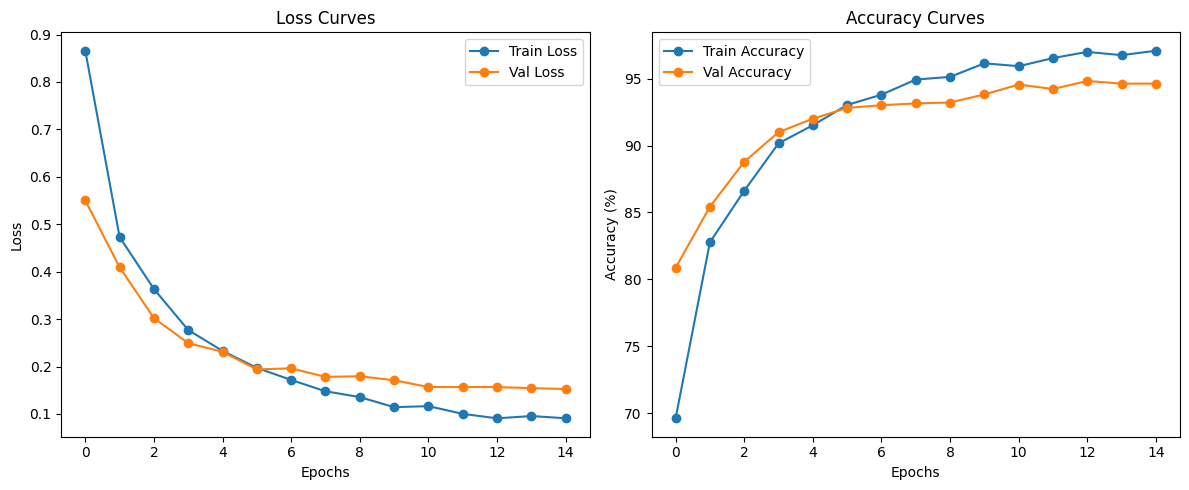

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate_initial)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)

train_model(model, train_loader, val_loader, num_epochs=num_epochs_initial,
            optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 94.63%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.94      0.88      0.91       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.98      1.00      0.99       148
             betel_Healthy Leaf       0.90      0.94      0.92       148
                 tea_algal_spot       0.94      1.00      0.97       150
               tea_brown_blight       0.88      0.94      0.91       130
                tea_gray_blight       0.96      0.87      0.91       150
                    tea_healthy       0.93      0.95      0.94       150
                 tea_helopeltis       0.97      0.93      0.95       150
                   tea_red_spot       0.96      0.97      0.96       150

                       accuracy                           0.95      1472
                      macro avg       0.95      0.95      0.95      1472
  

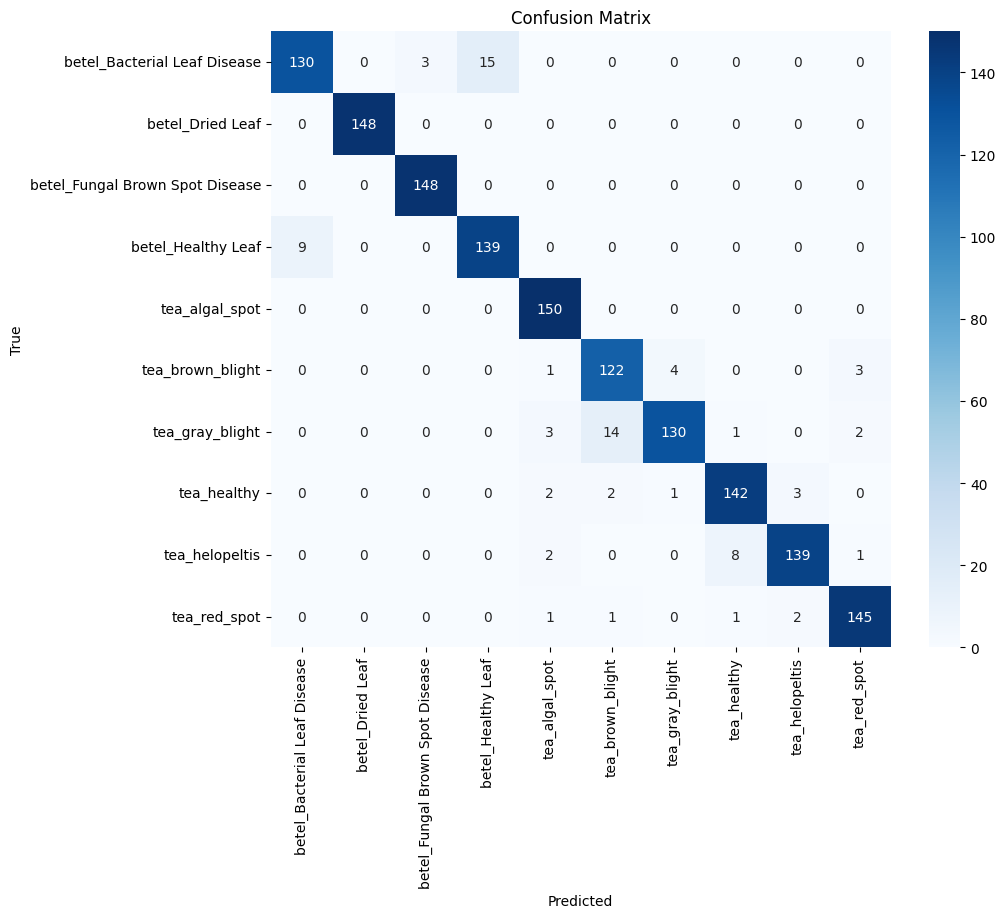

In [16]:
evaluate_model(model, test_loader, device, class_names)

In [17]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [18]:
torch.cuda.empty_cache()

In [19]:
# ====== Stage 2: Fine-Tune the Last N Layers ======
n_layers_to_unfreeze = 20  # Adjust as needed
print(f"\nStage 2: Fine-tuning the last {n_layers_to_unfreeze} layers.")
unfreeze_last_n_layers_and_attention(model, n_layers_to_unfreeze)
print_model_summary(model)


Stage 2: Fine-tuning the last 20 layers.

==== Model Summary ====
Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualCA: 2-2                     [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           904
│    └─InvertedResidualCA: 2-3                     [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           (3,864)
│    └─InvertedResidualCA: 2-4       

Epoch 1/15 | Train Loss: 0.1501 Acc: 94.76% | Val Loss: 0.1930 Acc: 93.69% | Time: 29.89s | 231.04 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/15 | Train Loss: 0.1181 Acc: 95.57% | Val Loss: 0.1589 Acc: 94.22% | Time: 30.39s | 227.23 samples/s
Best model saved to best_model.pth
Epoch 3/15 | Train Loss: 0.0942 Acc: 96.92% | Val Loss: 0.1563 Acc: 94.56% | Time: 31.07s | 222.25 samples/s
Best model saved to best_model.pth
Epoch 4/15 | Train Loss: 0.0782 Acc: 97.18% | Val Loss: 0.1589 Acc: 94.36% | Time: 31.67s | 218.03 samples/s
Epoch 5/15 | Train Loss: 0.0707 Acc: 97.67% | Val Loss: 0.1701 Acc: 94.69% | Time: 30.99s | 222.85 samples/s
Best model saved to best_model.pth
Epoch 6/15 | Train Loss: 0.0598 Acc: 97.87% | Val Loss: 0.1693 Acc: 95.16% | Time: 30.74s | 224.65 samples/s
Best model saved to best_model.pth
Epoch 7/15 | Train Loss: 0.0439 Acc: 98.52% | Val Loss: 0.1595 Acc: 95.37% | Time: 31.66s | 218.11 samples/s
Best model saved to best_model.pth
Epoch 8/15 | Train Loss: 0.0440 Acc: 98.41% | Val Loss: 0.1614 Acc: 94.90% | Time: 30.68s | 225.06 samples/s
Epoch 9/15 | Train Loss: 0.0350 Acc: 98.87% | Val Loss: 0.1454

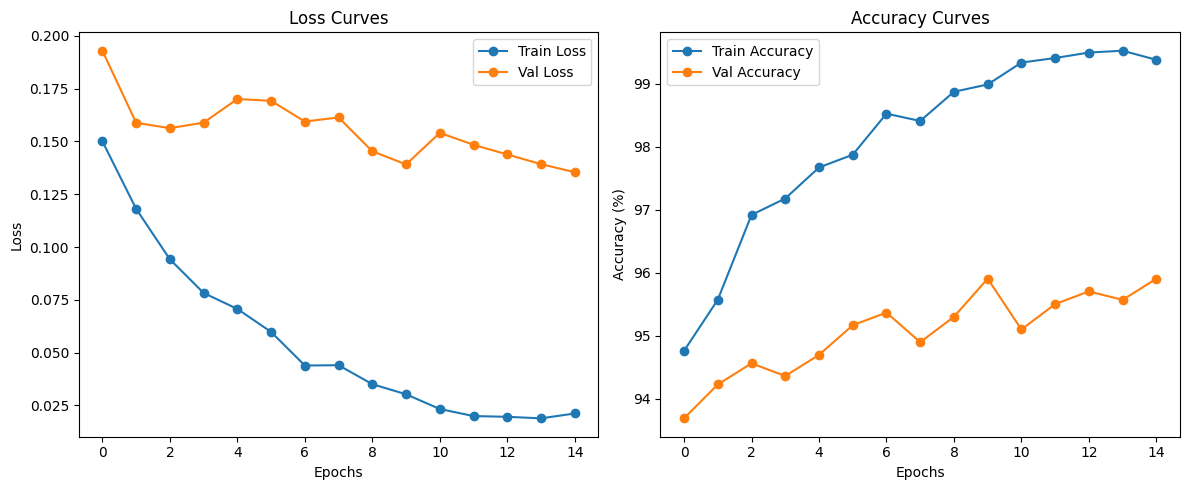

In [20]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate_initial)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)

train_model(model, train_loader, val_loader, num_epochs=num_epochs_initial,
            optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 96.33%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.94      0.90      0.92       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.99      1.00      1.00       148
             betel_Healthy Leaf       0.91      0.95      0.93       148
                 tea_algal_spot       0.99      0.99      0.99       150
               tea_brown_blight       0.92      0.95      0.94       130
                tea_gray_blight       0.96      0.93      0.94       150
                    tea_healthy       0.95      0.97      0.96       150
                 tea_helopeltis       0.98      0.95      0.97       150
                   tea_red_spot       0.98      0.99      0.99       150

                       accuracy                           0.96      1472
                      macro avg       0.96      0.96      0.96      1472
  

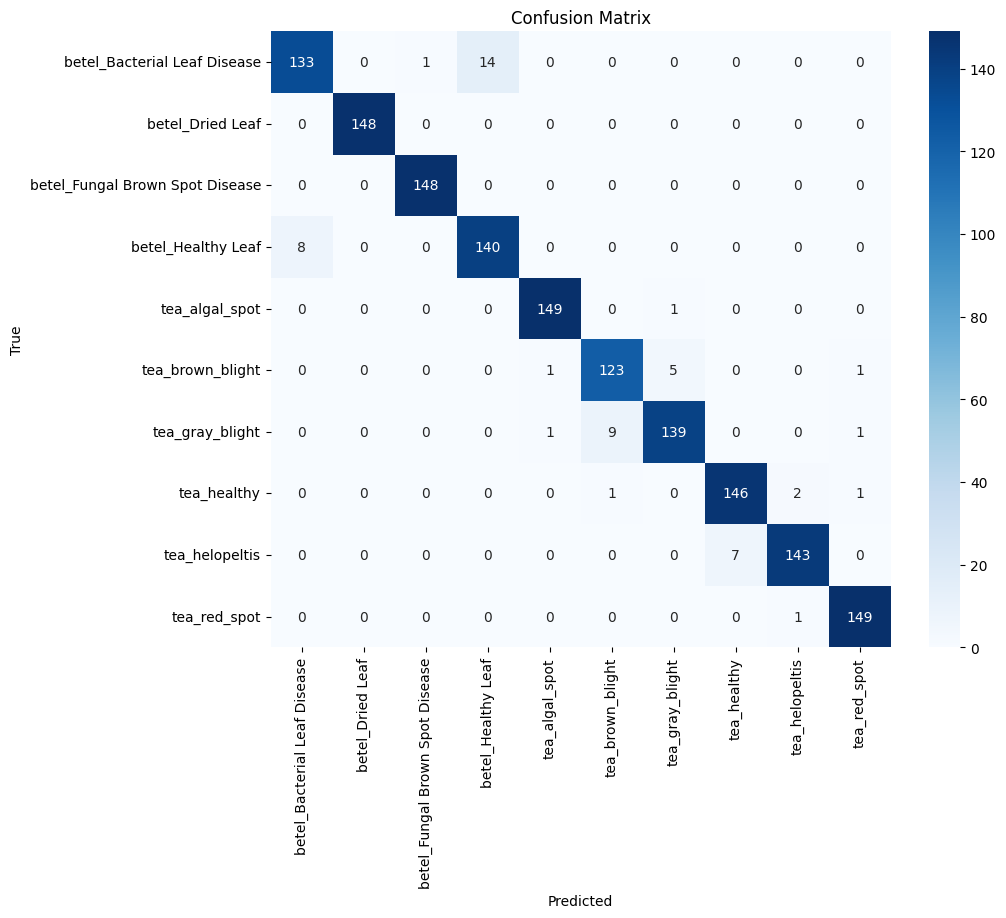

In [21]:
evaluate_model(model, test_loader, device, class_names)

In [22]:
show_visualizations(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [23]:
torch.cuda.empty_cache()